In [1]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [2]:
%cd /content/drive/MyDrive/ColabNotebooks/

/content/drive/MyDrive/ColabNotebooks


In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

pd.set_option('display.max_columns', None)

In [4]:
df = pd.read_csv('synthetic_student_data_new.csv')

##EDA

In [5]:
df.head()

,StudentID,EntryYear,Year,Semester,Module,AttemptType,Grade,GradePoints,Credits,IncludedInGPA,Forgiven
0,20200001,2020,1,1,IT,Original,B,3.0,3,True,False
1,20200001,2020,1,1,CommSkills,Original,A,4.0,3,True,False
2,20200001,2020,1,1,Eng1,Original,A,4.0,3,True,False
3,20200001,2020,1,2,IT,Original,A,4.0,3,True,False
4,20200001,2020,1,2,IntroCS,Original,A,4.0,3,True,False


In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 21521 entries, 0 to 21520
Data columns (total 11 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   StudentID      21521 non-null  int64  
 1   EntryYear      21521 non-null  int64  
 2   Year           21521 non-null  int64  
 3   Semester       21521 non-null  int64  
 4   Module         21521 non-null  object 
 5   AttemptType    21521 non-null  object 
 6   Grade          21521 non-null  object 
 7   GradePoints    21521 non-null  float64
 8   Credits        21521 non-null  int64  
 9   IncludedInGPA  21521 non-null  bool   
 10  Forgiven       21521 non-null  bool   
dtypes: bool(2), float64(1), int64(5), object(3)
memory usage: 1.5+ MB


In [7]:
df.duplicated().sum()

np.int64(0)

In [8]:
import matplotlib.ticker as mtick
import seaborn as sns
from scipy import stats

pd.set_option('display.float_format', '{:.2f}'.format)

# Consistent style for all plots
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams.update({'figure.dpi': 120, 'figure.figsize': (10, 4)})


In [9]:
df.shape

(21521, 11)

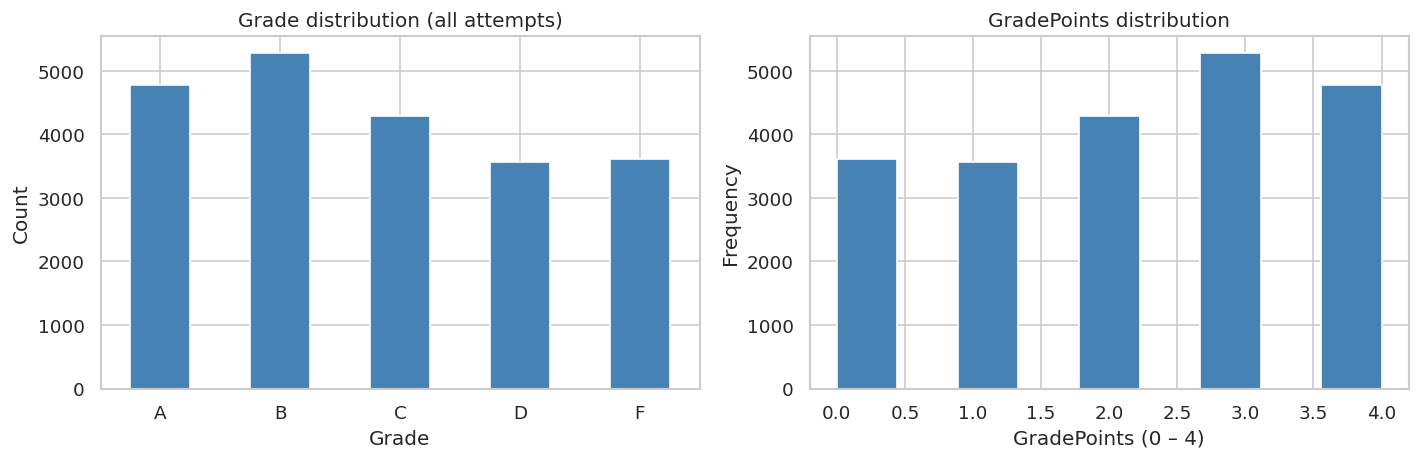


Grade → GradePoints mapping (should be 1-to-1):
       min  max  nunique
Grade                   
A     4.00 4.00        1
B     3.00 3.00        1
C     2.00 2.00        1
D     1.00 1.00        1
F     0.00 0.00        1


In [10]:
grade_order = ['A', 'B', 'C', 'D', 'F']
grade_order = [g for g in grade_order if g in df['Grade'].unique()]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Letter grade counts
grade_counts = df['Grade'].value_counts().reindex(grade_order, fill_value=0)
grade_counts.plot(kind='bar', ax=axes[0], color='steelblue', edgecolor='white')
axes[0].set_title('Grade distribution (all attempts)')
axes[0].set_xlabel('Grade')
axes[0].set_ylabel('Count')
axes[0].tick_params(axis='x', rotation=0)

# GradePoints distribution
df['GradePoints'].plot(kind='hist', bins=9, ax=axes[1],
                       color='steelblue', edgecolor='white')
axes[1].set_title('GradePoints distribution')
axes[1].set_xlabel('GradePoints (0 – 4)')
plt.tight_layout()
plt.show()

# Verify mapping is consistent
print("\nGrade → GradePoints mapping (should be 1-to-1):")
print(df.groupby('Grade')['GradePoints'].agg(['min', 'max', 'nunique']))


Attempt type breakdown:
AttemptType
Original    18000
Resit        3521
Name: count, dtype: int64

Overall resit rate: 16.4%

Resit rate by module (%):
Module
Research         17.40
CommSkills       17.10
Maths1           17.10
IntroCS          17.00
Eng1             16.90
OOP              16.80
DataStructures   16.50
Algorithms       16.40
Networks         16.30
Maths2           16.10
IT               16.00
Statistics       15.60
SoftEng          15.50
AI               15.40
Eng2             15.20


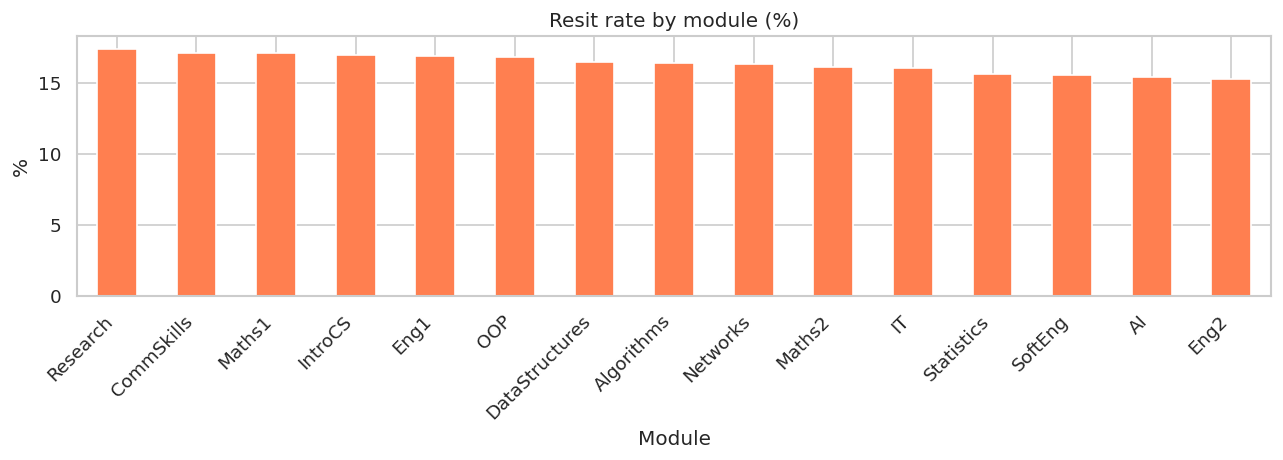

In [11]:
attempt_counts = df['AttemptType'].value_counts()
resit_pct = attempt_counts.get('Resit', 0) / len(df) * 100
print(f"Attempt type breakdown:\n{attempt_counts}\n")
print(f"Overall resit rate: {resit_pct:.1f}%")

# Resit rate per module
resit_by_module = (
    df.groupby('Module')['AttemptType']
    .apply(lambda x: (x == 'Resit').sum() / len(x) * 100)
    .sort_values(ascending=False)
)
print("\nResit rate by module (%):")
print(resit_by_module.round(1).to_string())

resit_by_module.plot(kind='bar', color='coral', edgecolor='white', figsize=(11, 4))
plt.title('Resit rate by module (%)')
plt.ylabel('%')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

##Defining Target Variable

In [12]:
PROBATION_THRESHOLD = 2.0

# Keep only rows that count toward GPA
gpa_rows = df[df['IncludedInGPA'] == True].copy()
gpa_rows['weighted'] = gpa_rows['GradePoints'] * gpa_rows['Credits']

# Compute weighted GPA per student
student_gpa = (
    gpa_rows.groupby('StudentID')
    .apply(lambda x: x['weighted'].sum() / x['Credits'].sum())
    .reset_index(name='GPA')
)

# Binary label: 1 = at risk, 0 = not at risk
student_gpa['at_risk'] = (student_gpa['GPA'] < PROBATION_THRESHOLD).astype(int)

print(student_gpa.head(10))
print(f"\nAt-risk students : {student_gpa['at_risk'].sum()}")
print(f"Total students   : {len(student_gpa)}")


   StudentID  GPA  at_risk
0   20200001 3.56        0
1   20200002 0.67        1
2   20200003 2.39        0
3   20200004 1.33        1
4   20200005 3.50        0
5   20200006 2.56        0
6   20200007 0.83        1
7   20200008 3.06        0
8   20200009 0.89        1
9   20200010 3.50        0

At-risk students : 378
Total students   : 1000


/tmp/ipykernel_7526/3162443379.py:10: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(lambda x: x['weighted'].sum() / x['Credits'].sum())


In [13]:
print("Class distribution of 'at_risk':")
print(student_gpa['at_risk'].value_counts())
print("\nClass distribution percentage:")
print(student_gpa['at_risk'].value_counts(normalize=True) * 100)

Class distribution of 'at_risk':
at_risk
0    622
1    378
Name: count, dtype: int64

Class distribution percentage:
at_risk
0   62.20
1   37.80
Name: proportion, dtype: float64


### Feature Engineering: Aggregating Student-Level Features

In [14]:
# Aggregate features from the original DataFrame (df) at the StudentID level
student_features = df.groupby('StudentID').agg(
    entry_year=('EntryYear', 'first'),
    total_credits_attempted=('Credits', 'sum'),
    num_resit_attempts=('AttemptType', lambda x: (x == 'Resit').sum()),
    num_failed_modules=('Grade', lambda x: (x == 'F').sum())
).reset_index()

# Merge these new features with the student_gpa DataFrame
student_gpa = pd.merge(student_gpa, student_features, on='StudentID', how='left')

print("Student GPA DataFrame with new features:")
display(student_gpa.head())

Student GPA DataFrame with new features:


,StudentID,GPA,at_risk,entry_year,total_credits_attempted,num_resit_attempts,num_failed_modules
0,20200001,3.56,0,2020,54,0,0
1,20200002,0.67,1,2022,93,13,11
2,20200003,2.39,0,2020,63,3,1
3,20200004,1.33,1,2022,78,8,11
4,20200005,3.50,0,2022,54,0,0


### Data Preprocessing for Machine Learning

1.  **Separating Features and Target:** Defining `X` (features) and `y` (target variable).
2.  **Identifying Feature Types:** Determining which features are numerical and which are categorical.
3.  **Scaling Numerical Features:** Using `StandardScaler` to normalize numerical features.
4.  **Encoding Categorical Features:** Using `OneHotEncoder` for any categorical features (though `entry_year` is currently numerical, it could be treated as categorical if desired).
5.  **Train-Test Split:** Dividing the dataset into training and testing sets to evaluate model performance.

In [15]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

X = student_gpa.drop(['StudentID', 'GPA', 'at_risk'], axis=1)
y = student_gpa['at_risk']

#Identifying Feature Types
numerical_features = ['total_credits_attempted', 'num_resit_attempts', 'num_failed_modules', 'entry_year']
categorical_features = [] # No explicit categorical features after aggregation yet

In [16]:
#Creating a preprocessing pipeline with ColumnTransformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', StandardScaler(), numerical_features),
    ])

#Train-Test Split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

In [19]:
#Looking at the splits
print("Original feature names:", X.columns.tolist())
print(f"X_train shape: {X_train.shape}")
print(f"X_test shape: {X_test.shape}")
print(f"y_train shape: {y_train.shape}")
print(f"y_test shape: {y_test.shape}")

Original feature names: ['entry_year', 'total_credits_attempted', 'num_resit_attempts', 'num_failed_modules']
X_train shape: (800, 4)
X_test shape: (200, 4)
y_train shape: (800,)
y_test shape: (200,)


In [20]:
# Fit and transform the training data
X_train_processed = preprocessor.fit_transform(X_train)

# Transform the test data
X_test_processed = preprocessor.transform(X_test)

print("\nFirst 5 rows of processed X_train (scaled numerical features):")
print(X_train_processed[:5])


First 5 rows of processed X_train (scaled numerical features):
[[-0.73344953 -0.73344953 -0.82075852  1.3345156 ]
 [-1.02712302 -1.02712302 -0.82075852 -0.45078955]
 [ 0.44124441  0.44124441  1.23685336  1.3345156 ]
 [-1.02712302 -1.02712302 -0.82075852 -0.45078955]
 [-1.02712302 -1.02712302 -0.59213497  1.3345156 ]]


### Model Training and Evaluation

In [21]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix

# Initialize and train the Logistic Regression model
model = LogisticRegression(random_state=42, solver='liblinear')
model.fit(X_train_processed, y_train)

print("Model training complete.")

Model training complete.


### Model Prediction and Evaluation

After training, we'll use the model to make predictions on the test set and evaluate its performance using several metrics. Given the class imbalance, `accuracy` alone might be misleading, so we'll also look at `precision`, `recall`, `f1-score`, and `ROC AUC`.


Model Evaluation:
Accuracy: 0.9500
Precision: 0.9459
Recall: 0.9211
F1-Score: 0.9333
ROC AUC: 0.9907

Confusion Matrix:
[[120   4]
 [  6  70]]


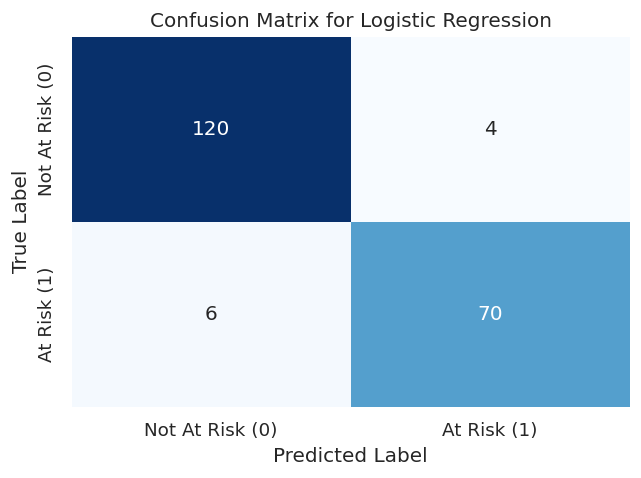

In [22]:
# Make predictions on the processed test data
y_pred = model.predict(X_test_processed)
y_prob = model.predict_proba(X_test_processed)[:, 1] # Probabilities for the positive class (at_risk=1)

# Evaluating the model
print("\nModel Evaluation:")
print(f"Accuracy: {accuracy_score(y_test, y_pred):.4f}")
print(f"Precision: {precision_score(y_test, y_pred):.4f}")
print(f"Recall: {recall_score(y_test, y_pred):.4f}")
print(f"F1-Score: {f1_score(y_test, y_pred):.4f}")
print(f"ROC AUC: {roc_auc_score(y_test, y_prob):.4f}")

# Display Confusion Matrix
conf_matrix = confusion_matrix(y_test, y_pred)
print("\nConfusion Matrix:")
print(conf_matrix)

plt.figure(figsize=(6, 4))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not At Risk (0)', 'At Risk (1)'], yticklabels=['Not At Risk (0)', 'At Risk (1)'])
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix for Logistic Regression')
plt.show()

In [23]:
import joblib

model_filename = 'logistic_regression_at_risk_model.joblib'

# saving trained model
joblib.dump(model, model_filename)

print(f"Model saved successfully to {model_filename}")

Model saved successfully to logistic_regression_at_risk_model.joblib


You can now load this model later using `loaded_model = joblib.load(model_filename)` and use it to make predictions on new data.